You can order print and ebook versions of *Think Bayes 2e* from
[Bookshop.org](https://bookshop.org/a/98697/9781492089469) and
[Amazon](https://amzn.to/334eqGo).

# Tracking an Outbreak with Mark and Recapture

Bayesian statistics is not as hard as people think -- you don't need a graduate degree in statistics to get started, and with a computational approach, you don't need a lot of math.
And with AI tools getting better and better, working with Bayesian methods is a lot easier than it used to be.

As an example, I'll use an exercise from Chapter 15 of [*Think Bayes*](https://allendowney.github.io/ThinkBayes2/chap15.html), which is about [mark and recapture modeling](https://en.wikipedia.org/wiki/Mark_and_recapture), a method originally developed for ecology, but applicable in many other domains.

In epidemiology, we can use mark and recapture to estimate the number of cases in a disease outbreak. For example, we might have several lists of cases from different sources. The lists are almost certainly incomplete, so we would like to estimate the total number of cases, including cases that don't appear on any of the lists.

If we can match individuals across lists, we can count the number of cases that appear on multiple lists. And the pattern of overlaps is informative: few repeats suggest many missing cases; many repeats suggest we have seen most of the cases.

In [this excellent paper](https://doi.org/10.1002/9781118445112.stat04855.pub2), 
Anne Chao reviews this approach and presents an example: a hepatitis A outbreak among students at a college in northern Taiwan in 1995.

Three lists of cases were available:

1. List P (135 cases): serum tests from the Institute of Preventive Medicine of Taiwan.
2. List Q (122 cases): cases reported by local hospitals to the National Quarantine Service.
3. List E (126 cases): questionnaires collected by epidemiologists.

Across the three lists, there were 271 distinct students.
The question is how many infected students were never listed.

To find an answer, we'll try two models: a simple one that assumes all students are equally likely to appear on a given list, and a more realistic model that assumes some cases are more detectable than others.
We'll see that the first model tends to underestimate the number of cases.
The second model is better!

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkBayes2/blob/master/examples/hepatitis.ipynb).

In [1]:
# install empiricaldist if necessary
try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
# Get utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/ThinkBayes2/raw/master/soln/utils.py')

In [3]:
# Make sure we have PyMC and arviz
try:
    import pymc
    import arviz
except ImportError:
    !pip install pymc arviz

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.stats import norm

import pymc as pm
import arviz as az

from utils import decorate, set_pyplot_params

In [5]:
np.random.seed(0)
np.set_printoptions(legacy='1.25')
set_pyplot_params()

## The Data

The data we need are in Chao's paper, summarized by listing the number of cases that appeared on all three lists, and the number that appear on each combination of lists.

```
P  Q  E   count
1  1  1   28
1  1  0   21
1  0  1   17
1  0  0   69
0  1  1   18
0  1  0   55
0  0  1   63
0  0  0   ??
```

The last entry, which we'll denote `k000`, is the number of cases that don't appear on any list. That's what we'll estimate!

Here's the data in array form.

In [6]:
# k000 is unknown; the remaining seven cells are observed
observed = np.array([63, 55, 18, 69, 17, 21, 28])
num_seen = observed.sum()
num_seen

271

The number of cases that appear on at least one list, `num_seen`, is 271. 
Once we estimate `k000`, we can compute the total number of cases, `N = num_seen + k000`.

## Homogeneous model

We'll start with what I'll call the homogeneous model, because it assumes that every infected person has the same probability of appearing on a given list -- but different probabilities, `p_P`, `p_Q`, and `p_E`, for the three lists.

With that assumption, the probability of each combination, `000` through `111` is the product of combinations of `p_P`, `p_Q`, `p_E` and their complements (see the model below).

For the prior distribution of `k000` we'll use a Poisson distribution with a weakly informative hyperprior on the Poisson mean.
For the list probabilities, the prior is a Beta distribution with parameters (1, 1), which is uniform from 0 to 1.

Here's the model.

In [7]:
coords = {"list": ["P", "Q", "E"]}

In [8]:
with pm.Model(coords=coords) as model:
    p = pm.Beta("p", alpha=1, beta=1, dims="list")
    p_P, p_Q, p_E = p[0], p[1], p[2]

    mu = pm.HalfNormal("mu", sigma=100)
    k000 = pm.Poisson("k000", mu=mu)
    N = pm.Deterministic("N", num_seen + k000)

    q_P, q_Q, q_E = 1 - p_P, 1 - p_Q, 1 - p_E
    probs = pm.math.stack(
        [
            q_P * q_Q * q_E,  # 000
            q_P * q_Q * p_E,  # 001
            q_P * p_Q * q_E,  # 010
            q_P * p_Q * p_E,  # 011
            p_P * q_Q * q_E,  # 100
            p_P * q_Q * p_E,  # 101
            p_P * p_Q * q_E,  # 110
            p_P * p_Q * p_E,  # 111
        ]
    )
    counts = pm.math.stack([k000, *observed])

    pm.Potential(
        "likelihood",
        pm.logp(pm.Multinomial.dist(n=N, p=probs), counts),
    )
    

As a technical note, you might wonder why we can't write the likelihood like this:

```    
likelihood = pm.Multinomial("likelihood", n=N, p=probs, observed=counts)
```

The problem is that the value we pass as `observed` has to be constant -- it can't be a random variable or contain any random variables -- and `counts` contains the random variable `k000`. 
Instead we use `Potential` to compute the log likelihood of the data directly.

Here's a graphical representation of the model.

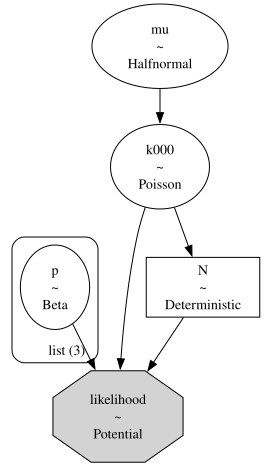

In [9]:
pm.model_to_graphviz(model)

Notice that `k000` affects the likelihood of the data in two ways: directly as one of the counts and indirectly as a term of `N = num_seen + k000`.

In [10]:
with model:
    idata = pm.sample(2000, tune=2000, random_seed=42, target_accept=0.9)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [p, mu]
>Metropolis: [k000]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [11]:
az.summary(idata, var_names=["N", "p", "mu", "k000"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,385.172,20.810,351.000,425.000,1.256,0.913,279.0,431.0,1.01
p[P],0.352,0.030,0.296,0.410,0.001,0.001,642.0,1371.0,1.00
p[Q],0.318,0.029,0.266,0.376,0.001,0.000,740.0,1733.0,1.00
p[E],0.329,0.029,0.271,0.382,0.001,0.001,714.0,1735.0,1.00
mu,113.782,22.871,73.256,158.240,1.263,0.821,330.0,605.0,1.01
k000,114.172,20.810,80.000,154.000,1.256,0.913,279.0,431.0,1.01


The model samples reasonably well. Here are the posterior distributions.

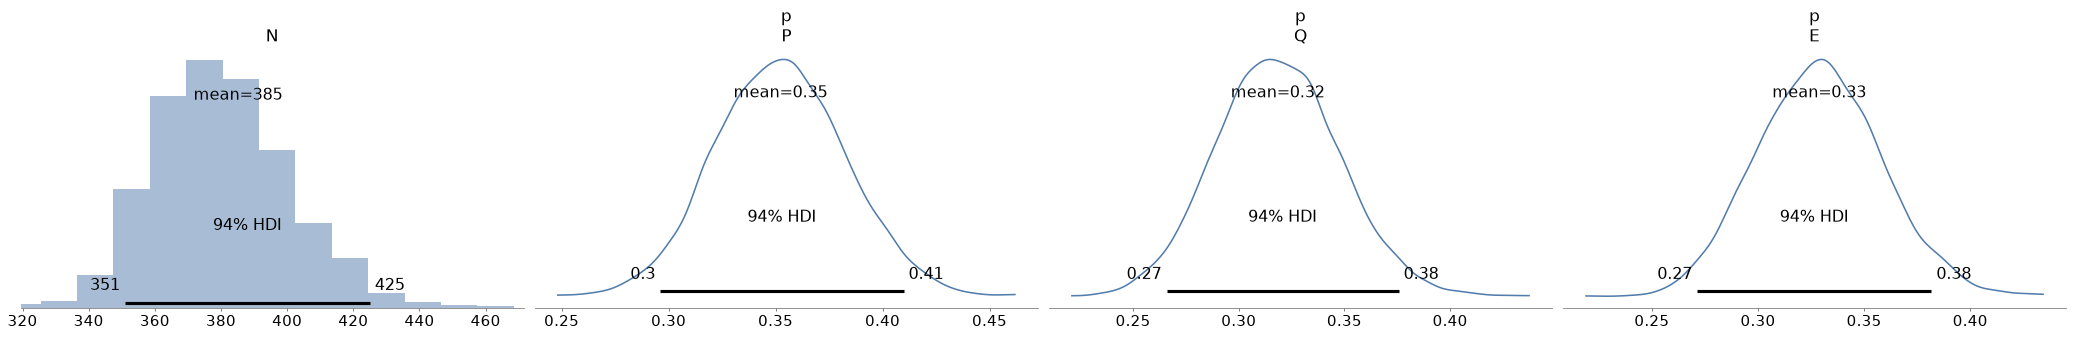

In [12]:
az.plot_posterior(idata, var_names=["N", "p"])
decorate()

And here's the estimated value of `N` with a 90% CI.

In [13]:
az.summary(idata, var_names=["N"], hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,385.172,20.81,352.0,418.0,1.256,0.913,279.0,431.0,1.01


The posterior mean, about 385, is consistent with Chao’s independence estimator `N̂0` and with the solution in Think Bayes.
Unfortunately, it turns out to be too low. A later campus-wide serum screen put the true number of infections around 545.

The homogeneous model treats each infected student as equally likely to appear on a given list.
It also assumes that, after accounting for the different coverage of the three lists, appearing on one list provides no information about appearing on another.
Both assumptions are questionable.

In reality, some students are easier to detect than others — for example, because they had more severe symptoms or greater contact with medical services.
Such students would be more likely to appear on all three lists, while students with mild or asymptomatic infections might appear on none.

If that's true, the data will contain more repeated observations than the homogeneous model expects.
In that case, the homogeneous model interprets the observed overlap as evidence that the lists have covered most of the population, and it tends to underestimate the number of infections.
And in this example, we can see that it did.

So let's build a better model.

## Individual heterogeneity

We'll assume that each person has a level of detectability, $z_k$, and each list has a baseline detection level $\alpha_P$, $\alpha_Q$, $\alpha_E$.
For a person with detectability $z_k$, the chance they appear on list `j` is `p_{kj}`, where

$$\mathrm{logit}(p_{kj}) = \alpha_j + \sigma z_k$$

Here $\sigma$ controls how much influence individual detectability has, compared to the baseline detection levels.
A person with high $z_k$ is more likely to appear on more than one list; people with low detectability are more likely to be missed entirely.

To implement this model, we don't need a latent variable for every person.
Instead, we'll assume there are 21 detectability levels, `z_k`, and assign each level a weight, `w_k`, that represents the fraction of people in the population at that level.
Then we can compute the cell probabilities using a weighted sum of the cell probabilities conditioned on `z_k`.
As an example, here is the probability for cell 101:

$$\pi_{101} = \sum_k w_k \, P(101 \mid z_k)$$

And similarly for the other cells.

Before we build the model, we'll precompute the values of $z$ and the corresponding weights (using the PDF of a normal distribution to make a bell curve).

In [14]:
z = np.linspace(-4, 4, 21)
weights = norm.pdf(z)
weights /= weights.sum()

And precompute the pattern of detection/non-detection for each cell.

In [15]:
from itertools import product

patterns = np.array(list(product([0, 1], repeat=3)), dtype=float)
patterns

array([[0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 1.],
       [1., 0., 0.],
       [1., 0., 1.],
       [1., 1., 0.],
       [1., 1., 1.]])

Now here's a function that builds the model.
The argument `sigma_prior_scale` is the scale of the half-normal prior on $\sigma$; we'll vary it later to check sensitivity.

In [16]:
def make_heterogeneity_model(sigma_prior_scale=2):
    with pm.Model(coords=coords) as model:
        alpha = pm.Normal("alpha", mu=0, sigma=1.5, dims="list")
        sigma = pm.HalfNormal("sigma", sigma=sigma_prior_scale)

        # Probability someone with z=0 appears on each list
        p_typical = pm.Deterministic(
            "p_typical", pm.math.sigmoid(alpha), dims="list"
        )

        # Probability someone with each level of z appears on each list
        # shape: level × list
        logits = alpha[None, :] + sigma * z[:, None]
        p_z = pm.math.sigmoid(logits)

        # Population average probability of appearing on each list
        p_avg = pm.Deterministic(
            "p_avg",
            pm.math.sum(p_z * weights[:, None], axis=0),
            dims="list",
        )

        # Probability of each cell for each level of z and list
        # shape: cell × level × list
        y = patterns[:, None, :]
        cell_prob_given_z = pm.math.prod(
            p_z[None, :, :] ** y * (1 - p_z[None, :, :]) ** (1 - y),
            axis=2,
        )

        # Mixture over levels of z; shape: cell
        probs = pm.math.sum(cell_prob_given_z * weights[None, :], axis=1)
        probs = probs / pm.math.sum(probs)

        # The rest of this model is the same as the previous one
        mu = pm.HalfNormal("mu", sigma=100)
        k000 = pm.Poisson("k000", mu=mu)
        N = pm.Deterministic("N", num_seen + k000)

        counts = pm.math.stack([k000, *observed])
        pm.Potential(
            "likelihood",
            pm.logp(pm.Multinomial.dist(n=N, p=probs), counts),
        )
    return model

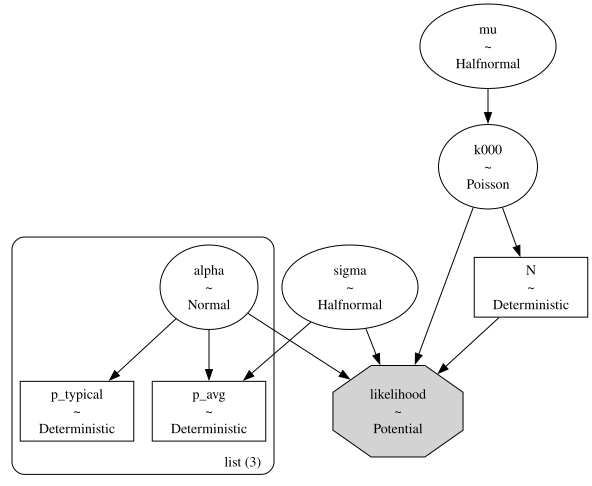

In [17]:
heterogeneity_model = make_heterogeneity_model()
pm.model_to_graphviz(heterogeneity_model)

In [18]:
with heterogeneity_model:
    idata_het = pm.sample(2000, tune=2000, random_seed=42)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k000]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


This model doesn't sample as well, but the results are stable enough for our purposes.

In [19]:
az.summary(
    idata_het,
    var_names=["N", "alpha", "sigma", "p_typical", "p_avg", "mu", "k000"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,491.111,59.044,381.000,601.000,12.049,3.917,23.0,131.0,1.13
alpha[P],-1.129,0.274,-1.666,-0.629,0.052,0.014,28.0,164.0,1.10
alpha[Q],-1.289,0.279,-1.813,-0.770,0.051,0.014,30.0,146.0,1.10
alpha[E],-1.237,0.280,-1.771,-0.721,0.052,0.015,29.0,129.0,1.10
sigma,0.923,0.240,0.484,1.384,0.040,0.012,35.0,222.0,1.09
p_typical[P],0.248,0.050,0.150,0.337,0.009,0.002,28.0,164.0,1.10
p_typical[Q],0.220,0.047,0.133,0.306,0.009,0.002,30.0,146.0,1.10
p_typical[E],0.229,0.048,0.139,0.318,0.009,0.002,29.0,129.0,1.10
p_avg[P],0.281,0.038,0.206,0.348,0.007,0.002,31.0,165.0,1.09
p_avg[Q],0.254,0.036,0.189,0.321,0.006,0.001,35.0,271.0,1.08


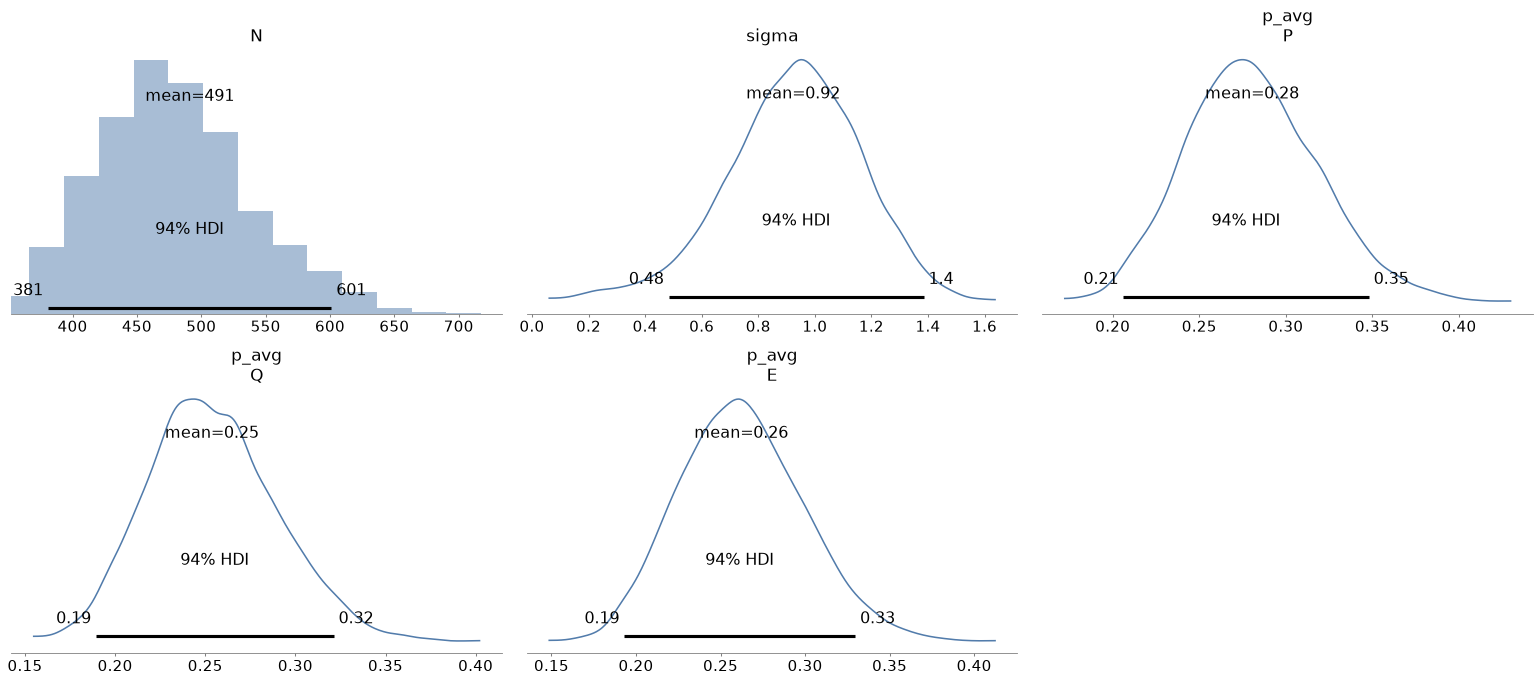

In [20]:
az.plot_posterior(idata_het, var_names=["N", "sigma", "p_avg"])
decorate()

In [21]:
az.summary(idata_het, var_names=["N"], hdi_prob=0.9)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
N,491.111,59.044,395.0,588.0,12.049,3.917,23.0,131.0,1.13


The mean is closer to the true value, 545.
And the 90% CI contains the true value.

But the price we pay for a more flexible model is a wider CI.
Here are the posterior distributions of the two models (the dashed line is the true value).

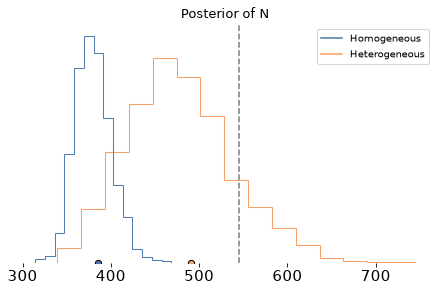

In [22]:
az.plot_density(
    [idata, idata_het],
    var_names=["N"],
    data_labels=["Homogeneous", "Heterogeneous"],
)
plt.axvline(545, ls='--', color='gray')
decorate(title="Posterior of N")

In [23]:
summary_ind = az.summary(idata, var_names=["N"], hdi_prob=0.9)
summary_het = az.summary(idata_het, var_names=["N"], hdi_prob=0.9)
pd.DataFrame(
    {
        "mean": [summary_ind.loc["N", "mean"], summary_het.loc["N", "mean"]],
        "hdi_5%": [summary_ind.loc["N", "hdi_5%"], summary_het.loc["N", "hdi_5%"]],
        "hdi_95%": [summary_ind.loc["N", "hdi_95%"], summary_het.loc["N", "hdi_95%"]],
    },
    index=["Homogeneous", "Heterogeneous"],
)

,mean,hdi_5%,hdi_95%
Homogeneous,385.172,352.0,418.0
Heterogeneous,491.111,395.0,588.0


## Sensitivity to Priors

With only seven observed cells the baselines $\alpha_j$, and $\sigma$ can trade off.
Larger $\sigma$ creates a subgroup with low probability of detection, which can support a larger unseen population.
So the upper tail of `N` may be prior-sensitive.

To check, we'll test a few values of `sigma_prior_scale`, which controls the width of the prior distribution of $\sigma$.

In [24]:
def fit_heterogeneity(sigma_prior_scale, random_seed=42):
    model = make_heterogeneity_model(sigma_prior_scale)
    with model:
        idata_s = pm.sample(
            1000, tune=1000, random_seed=random_seed, progressbar=False
        )
    return idata_s

In [25]:
sensitivity = []
for scale in [1.0, 2.0, 4.0]:
    idata_s = fit_heterogeneity(scale)
    s = az.summary(idata_s, var_names=["N", "sigma"], hdi_prob=0.9)
    sensitivity.append(
        {
            "HalfNormal scale": scale,
            "N mean": s.loc["N", "mean"],
            "N 5%": s.loc["N", "hdi_5%"],
            "N 95%": s.loc["N", "hdi_95%"],
            "sigma mean": s.loc["sigma", "mean"],
        }
    )

pd.DataFrame(sensitivity).round(1)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k000]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, sigma, mu]
>Metropolis: [k000]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is n

,HalfNormal scale,N mean,N 5%,N 95%,sigma mean
0,1.0,485.8,398.0,561.0,0.9
1,2.0,500.1,418.0,594.0,1.0
2,4.0,506.5,410.0,592.0,1.0


If the prior distribution of `sigma` is too narrow, it restrains the effect of individual variation, which biases the estimate of `N` downward.

But once it's large enough, it doesn't have much effect on the results.

## Discussion

This example demonstrates a feature of Bayesian modeling with PyMC: the ability to develop and test a model incrementally, adding features as needed and comparing successive iterations.

It also demonstrates the impact of AI tools on the development process for Bayesian models. The models in this example are moderately complex. Both of them use a `Potential` to compute a custom likelihood function, and the second involves array operations that might take some time to write, test, and debug. Using various AI tools, I was able to get both models working quickly -- which allowed time to inspect, test, and refine them.
And then I was able to test a few variations to make the models simpler and easier to explain.

I'm not sure I would say it was easy -- this kind of work still requires a fundamental understanding of Bayesian statistics and PyMC. But it is a lot easier than it used to be!

Copyright 2026 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)